In [1]:
import pandas as pd
import pymc as pm
import japanize_matplotlib
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import numpy as np
import arviz as az
import kagglehub

In [4]:
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 1.25M/1.25M [00:00<00:00, 2.07MB/s]

Extracting files...
Path to dataset files: /home/manaty/.cache/kagglehub/datasets/yeanzc/telco-customer-churn-ibm-dataset/versions/1


In [22]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")
print(df.isnull().sum())
print(df["Churn Reason"].unique())
df

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64
<ArrowStringArray>
[             'Competitor made better offer',
                                     'Moved',
             'Comp

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [23]:
competition_risk = ["Competitor made better offer", "Competitor had better devices", "Competitor offered higher download speeds", "Competitor offered more data"]
df_competition_risk = df[df["Churn Reason"].isin(competition_risk)]
len(df_competition_risk)

621

In [24]:
price_risk = ["Price too high", "Long distance charges", "Extra data charges", "Lack of affordable download/upload speed"]
df_price_risk = df[df["Churn Reason"].isin(price_risk)]
len(df_price_risk)

243

In [26]:
dissatisfation_risk = ["Product dissatisfaction", "Service dissatisfaction", "Network reliability", "Limited range of services","Lack of self-service on Website"]
df_dissatisfaction_risk = df[df["Churn Reason"].isin(dissatisfation_risk)]
len(df_dissatisfaction_risk)

426

In [27]:
support_risk = ["Poor expertise of online support", "Poor expertise of phone support", "Attitude of service provider", "Attitude of support person"]
df_support_risk = df[df["Churn Reason"].isin(support_risk)]
len(df_support_risk)

366

In [28]:
other_risk = ["Moved", "Deceased", "Don't know"]
df_other_risk = df[df["Churn Reason"].isin(other_risk)]
len(df_other_risk)

213

In [31]:
#解約理由のグループ化
competition_risk = ["Competitor made better offer", "Competitor had better devices", "Competitor offered higher download speeds", "Competitor offered more data"]
price_risk = ["Price too high", "Long distance charges", "Extra data charges", "Lack of affordable download/upload speed"]
dissatisfation_risk = ["Product dissatisfaction", "Service dissatisfaction", "Network reliability", "Limited range of services","Lack of self-service on Website"]
support_risk = ["Poor expertise of online support", "Poor expertise of phone support", "Attitude of service provider", "Attitude of support person"]
other_risk = ["Moved", "Deceased", "Don't know"]

df["competition_event"] = df["Churn Reason"].apply(lambda x:1 if x in competition_risk else 0)
df["price_event"] = df["Churn Reason"].apply(lambda x:1 if x in price_risk else 0)
df["dissatisfaction_event"] = df["Churn Reason"].apply(lambda x:1 if x in dissatisfation_risk else 0)
df["support_event"] = df["Churn Reason"].apply(lambda x:1 if x in support_risk else 0)
df["other_event"] = df["Churn Reason"].apply(lambda x:1 if x in other_risk else 0)


In [38]:
df["is_one_year"] = (df["Contract"] == "One year").astype(int)
df["is_two_year"] = (df["Contract"] == "Two year").astype(int)

t_obs_safe = df["Tenure Months"].values.astype(float) + 0.5
x1 = df["is_one_year"].values.astype(float)
x2 = df["is_two_year"].values.astype(float)

breaks = np.arange(0, 78, 6)
n_intervals = len(breaks) - 1
interval_idx = np.clip(np.searchsorted(breaks, t_obs_safe, side="right") - 1, 0, n_intervals-1)
exposure = t_obs_safe - breaks[interval_idx]

def build_cause_specific_model(event_col):
    event_obs = df[event_col].values.astype(float)
    with pm.Model() as m:
        h0 = pm.Gamma("h0", alpha=10, beta=10/0.065,  shape=n_intervals)
        beta1 = pm.Normal("beta1", mu=0, sigma=1)
        beta2 = pm.Normal("beta2", mu=0, sigma=1)

        log_hazard_ratio = beta1 * x1 + beta2 * x2
        h_i = h0[interval_idx] * pt.exp(log_hazard_ratio)

        log_lik = event_obs * pt.log(h_i) - h_i * exposure
        pm.Potential("loglike", pt.sum(log_lik))
    return m


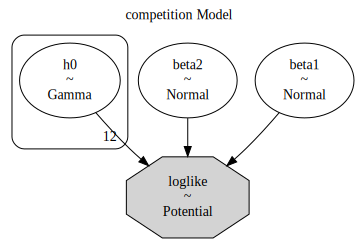

In [60]:
#競合他社の乗り換え
model_competition = build_cause_specific_model("competition_event")
g = pm.model_to_graphviz(model_competition)
g.graph_attr.update(
    label="competition Model",
    labelloc="t",
    fontdize="16"
)
g.render(filename="../models/competition_model_graph", format="png", cleanup=True)
g

In [41]:
with model_competition:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)
prior

/tmp/ipykernel_37557/544251541.py:2: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [beta1, beta2, h0]


<xarray.DataTree>
Group: /
├── Group: /prior
│       Dimensions:   (chain: 1, draw: 300, h0_dim_0: 12)
│       Coordinates:
│         * chain     (chain) int64 8B 0
│         * draw      (draw) int64 2kB 0 1 2 3 4 5 6 7 ... 293 294 295 296 297 298 299
│         * h0_dim_0  (h0_dim_0) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
│       Data variables:
│           beta2     (chain, draw) float64 2kB 1.254 0.6063 -1.34 ... -1.125 -0.7739
│           h0        (chain, draw, h0_dim_0) float64 29kB 0.07167 0.06342 ... 0.05625
│           beta1     (chain, draw) float64 2kB -1.649 1.406 0.7235 ... -0.501 -0.7213
│       Attributes:
│           created_at:                 2026-07-16T04:55:03.003468+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /prior_predictive
│       Attributes:
│           created_at:                 2026-07-16T04:55:03.004725+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
└── Group: /observed_data
        Attributes:
            created_at:                 2026-07-16T04:55:03.005155+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.0.1
            sample_dims:                []

h0 事前分布（平均）: [0.0653 0.0635 0.0649 0.065  0.0647 0.0641 0.0644 0.0648 0.0651 0.0682
 0.0657 0.0642]


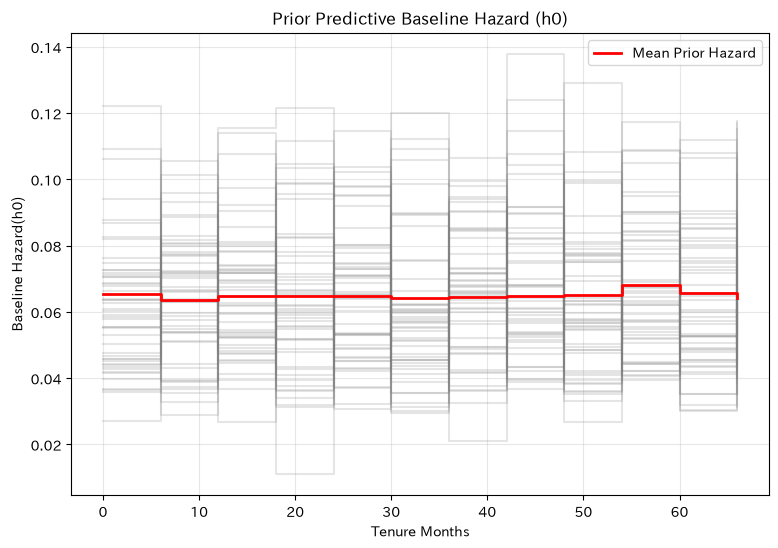

In [49]:
h0_prior = prior.prior["h0"].values.reshape(-1, n_intervals)
print("h0 事前分布（平均）:", h0_prior.mean(axis=0).round(4))
plt.figure(figsize=(9, 6))

num_lines = 50
for i in range(num_lines):
    plt.step(breaks[:-1], h0_prior[i], where="post", alpha=0.2, color="gray")

plt.step(breaks[:-1], h0_prior.mean(axis=0), where="post", color="red", linewidth=2, label="Mean Prior Hazard")

plt.xlabel("Tenure Months")
plt.ylabel("Baseline Hazard(h0)")
plt.title("Prior Predictive Baseline Hazard (h0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
    

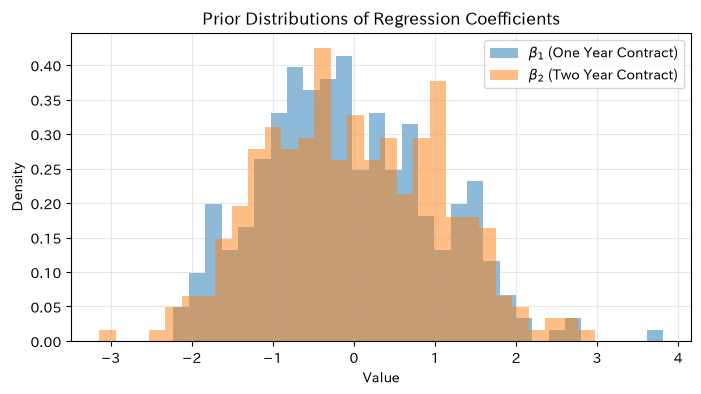

In [48]:

beta1_prior = prior.prior["beta1"].values.flatten()
beta2_prior = prior.prior["beta2"].values.flatten()
plt.figure(figsize=(8, 4))
plt.hist(beta1_prior, bins=30, alpha=0.5, density=True, label=r"$\beta_1$ (One Year Contract)")
plt.hist(beta2_prior, bins=30, alpha=0.5, density=True, label=r"$\beta_2$ (Two Year Contract)")


plt.title("Prior Distributions of Regression Coefficients")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
with model_competition:
    idata_competition = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_competition.sample_stats.diverging.sum()))
az.summary(idata_competition)

NUTS[numpyro]: [h0, beta1, beta2]
Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]


Running chain 0:   5%|████                                                                            | 200/4000 [00:

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta1,-1.212,0.14,-1.4,-0.99,7989,6088,1.00,0.0016,0.0011
beta2,-2.564,0.248,-3,-2.2,8071,6307,1.00,0.0028,0.0019
h0[0],0.06739,0.00433,0.061,0.075,10150,6127,1.00,4.3e-05,3.1e-05
h0[1],0.0546,0.0053,0.046,0.063,8886,5850,1.00,5.6e-05,4.1e-05
h0[2],0.0478,0.00574,0.039,0.058,10011,6134,1.00,5.7e-05,4.1e-05
h0[3],0.0385,0.00563,0.03,0.048,9995,6420,1.00,5.6e-05,3.9e-05
h0[4],0.0405,0.0062,0.031,0.051,9353,6131,1.00,6.3e-05,4.5e-05
h0[5],0.0337,0.00577,0.025,0.044,9768,6221,1.00,5.8e-05,4.2e-05
h0[6],0.0456,0.0076,0.034,0.058,10133,6015,1.00,7.5e-05,5.5e-05
h0[7],0.0401,0.0075,0.029,0.053,9161,6143,1.00,7.9e-05,5.7e-05


/tmp/ipykernel_37557/474955637.py:5: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [beta1, beta2, h0]


h0 事前分布（平均）: [0.0653 0.0635 0.0649 0.065  0.0647 0.0641 0.0644 0.0648 0.0651 0.0682
 0.0657 0.0642]


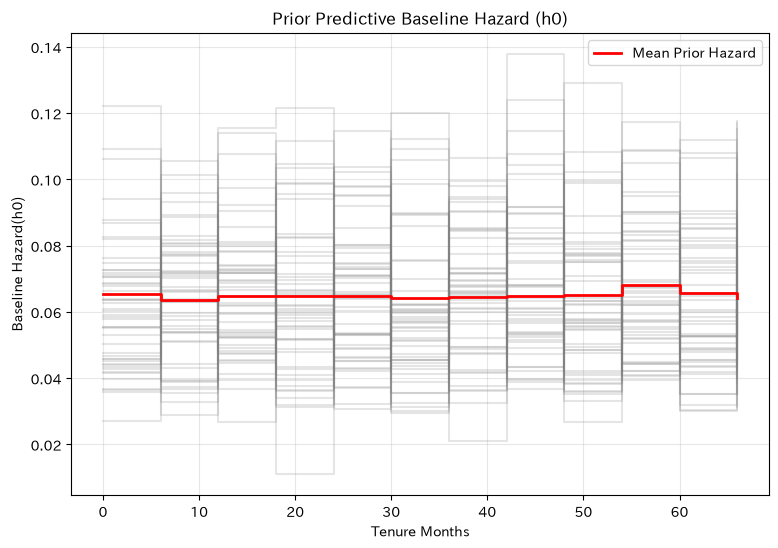

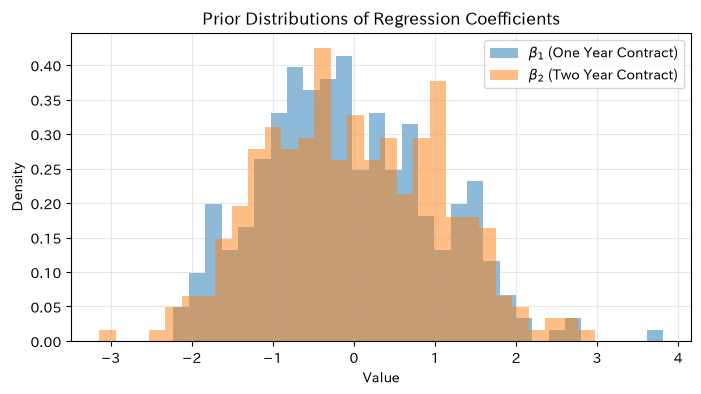

NUTS[numpyro]: [h0, beta1, beta2]
Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]


Running chain 1:   5%|████                                                                            | 200/4000 [00:

divergences: 0


NUTS[numpyro]: [h0, beta1, beta2]
Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]


Running chain 3:   0%|                                                                                            | 0

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta1,-1.957,0.235,-2.3,-1.6,7801,5530,1.00,0.0027,0.002
beta2,-2.752,0.309,-3.2,-2.3,7441,6421,1.00,0.0036,0.0025
h0[0],0.02704,0.00275,0.023,0.032,9794,6233,1.00,2.8e-05,2e-05
h0[1],0.02146,0.00333,0.016,0.027,8766,5865,1.00,3.5e-05,2.6e-05
h0[2],0.02363,0.00409,0.017,0.031,9371,5813,1.00,4.2e-05,3e-05
h0[3],0.018,0.00394,0.012,0.025,9364,6206,1.00,4e-05,3e-05
h0[4],0.03,0.00552,0.022,0.039,8938,5526,1.00,5.7e-05,4.3e-05
h0[5],0.0234,0.00502,0.016,0.032,9308,5747,1.00,5.1e-05,3.7e-05
h0[6],0.0268,0.00604,0.018,0.037,9364,5548,1.00,6.1e-05,4.6e-05
h0[7],0.0248,0.00607,0.016,0.035,9325,5659,1.00,6.2e-05,4.8e-05


In [54]:
#価格リスク
model_competition = build_cause_specific_model("price_event")

with model_competition:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)
prior

h0_prior = prior.prior["h0"].values.reshape(-1, n_intervals)
print("h0 事前分布（平均）:", h0_prior.mean(axis=0).round(4))
plt.figure(figsize=(9, 6))

num_lines = 50
for i in range(num_lines):
    plt.step(breaks[:-1], h0_prior[i], where="post", alpha=0.2, color="gray")

plt.step(breaks[:-1], h0_prior.mean(axis=0), where="post", color="red", linewidth=2, label="Mean Prior Hazard")

plt.xlabel("Tenure Months")
plt.ylabel("Baseline Hazard(h0)")
plt.title("Prior Predictive Baseline Hazard (h0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



beta1_prior = prior.prior["beta1"].values.flatten()
beta2_prior = prior.prior["beta2"].values.flatten()
plt.figure(figsize=(8, 4))
plt.hist(beta1_prior, bins=30, alpha=0.5, density=True, label=r"$\beta_1$ (One Year Contract)")
plt.hist(beta2_prior, bins=30, alpha=0.5, density=True, label=r"$\beta_2$ (Two Year Contract)")


plt.title("Prior Distributions of Regression Coefficients")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

with model_competition:
    idata_competition = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_competition.sample_stats.diverging.sum()))
az.summary(idata_competition)

with model_competition:
    idata_competition = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_competition.sample_stats.diverging.sum()))
az.summary(idata_competition)

/tmp/ipykernel_37557/1891146755.py:5: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [beta1, beta2, h0]


h0 事前分布（平均）: [0.0653 0.0635 0.0649 0.065  0.0647 0.0641 0.0644 0.0648 0.0651 0.0682
 0.0657 0.0642]


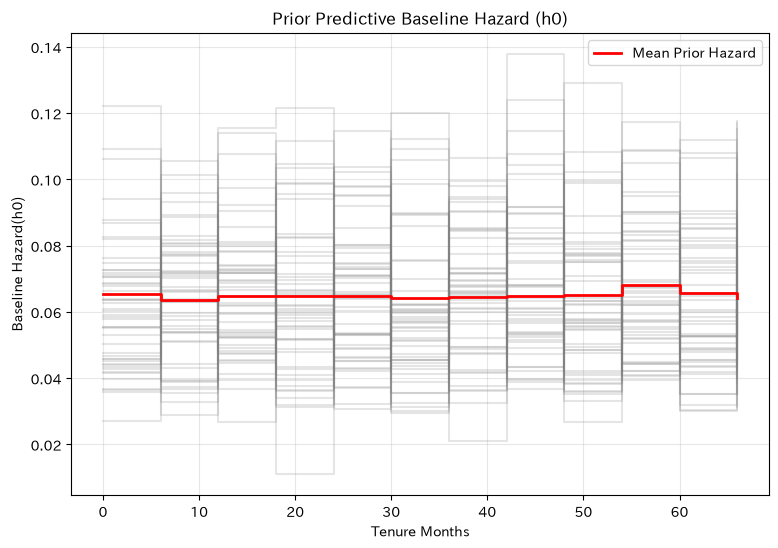

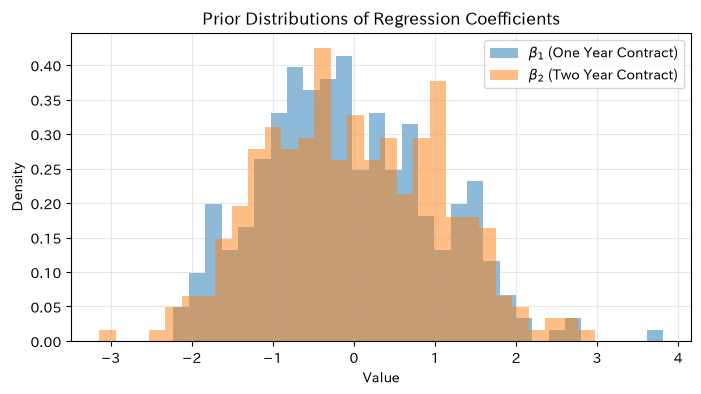

NUTS[numpyro]: [h0, beta1, beta2]
Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]


Running chain 3:   0%|                                                                                            | 0

divergences: 0


Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]


Running chain 0:   5%|████                                                                            | 200/4000 [00:01<00:02, 1528.18it/s]

Running ch

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta1,-1.617,0.185,-1.9,-1.3,8028,5720,1.00,0.0021,0.0015
beta2,-2.915,0.3,-3.4,-2.4,8006,6033,1.00,0.0033,0.0023
h0[0],0.0466,0.00359,0.041,0.052,9902,6054,1.00,3.6e-05,2.6e-05
h0[1],0.03808,0.00443,0.031,0.045,8590,6189,1.00,4.8e-05,3.5e-05
h0[2],0.0425,0.00548,0.034,0.051,9289,5702,1.00,5.6e-05,4.1e-05
h0[3],0.033,0.00528,0.025,0.042,9244,6053,1.00,5.4e-05,3.9e-05
h0[4],0.0323,0.00563,0.024,0.042,9756,6204,1.00,5.6e-05,4.2e-05
h0[5],0.0301,0.00562,0.022,0.04,9215,5458,1.00,5.8e-05,4.2e-05
h0[6],0.03,0.00629,0.021,0.041,9417,5884,1.00,6.3e-05,4.7e-05
h0[7],0.0413,0.0078,0.03,0.055,9293,6375,1.00,8.2e-05,6e-05


In [55]:
#不満リスク
model_competition = build_cause_specific_model("dissatisfaction_event")

with model_competition:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)
prior

h0_prior = prior.prior["h0"].values.reshape(-1, n_intervals)
print("h0 事前分布（平均）:", h0_prior.mean(axis=0).round(4))
plt.figure(figsize=(9, 6))

num_lines = 50
for i in range(num_lines):
    plt.step(breaks[:-1], h0_prior[i], where="post", alpha=0.2, color="gray")

plt.step(breaks[:-1], h0_prior.mean(axis=0), where="post", color="red", linewidth=2, label="Mean Prior Hazard")

plt.xlabel("Tenure Months")
plt.ylabel("Baseline Hazard(h0)")
plt.title("Prior Predictive Baseline Hazard (h0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



beta1_prior = prior.prior["beta1"].values.flatten()
beta2_prior = prior.prior["beta2"].values.flatten()
plt.figure(figsize=(8, 4))
plt.hist(beta1_prior, bins=30, alpha=0.5, density=True, label=r"$\beta_1$ (One Year Contract)")
plt.hist(beta2_prior, bins=30, alpha=0.5, density=True, label=r"$\beta_2$ (Two Year Contract)")


plt.title("Prior Distributions of Regression Coefficients")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

with model_competition:
    idata_competition = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_competition.sample_stats.diverging.sum()))
az.summary(idata_competition)

with model_competition:
    idata_competition = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_competition.sample_stats.diverging.sum()))
az.summary(idata_competition)

/tmp/ipykernel_37557/2929369025.py:5: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [beta1, beta2, h0]


h0 事前分布（平均）: [0.0653 0.0635 0.0649 0.065  0.0647 0.0641 0.0644 0.0648 0.0651 0.0682
 0.0657 0.0642]


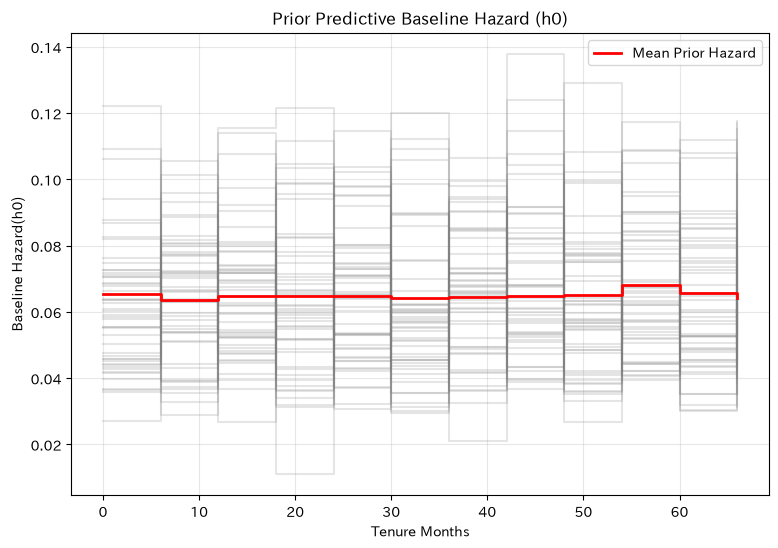

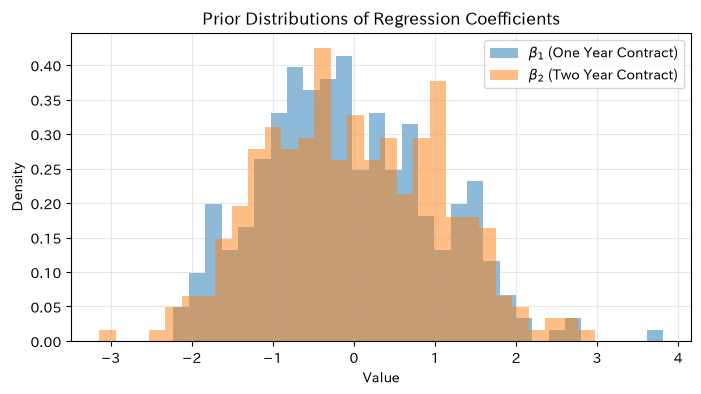

NUTS[numpyro]: [h0, beta1, beta2]
Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]


Running chain 3:   0%|                                                                                            | 0

divergences: 0


Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 3: 100%|████████████████████████████████████████████████████████████████████████████| 4000/4000 [-00:00<00:00, -30176.64it/s]


divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta1,-1.38,0.175,-1.7,-1.1,8099,6300,1.00,0.0019,0.0014
beta2,-3.353,0.35,-3.9,-2.8,8172,6460,1.00,0.0039,0.0028
h0[0],0.04181,0.00338,0.036,0.047,10427,5841,1.00,3.3e-05,2.4e-05
h0[1],0.03009,0.00394,0.024,0.037,9417,6062,1.00,4e-05,3e-05
h0[2],0.03376,0.00482,0.026,0.042,9399,6106,1.00,4.9e-05,3.6e-05
h0[3],0.0275,0.00477,0.02,0.035,9624,6303,1.00,4.8e-05,3.4e-05
h0[4],0.02402,0.00484,0.017,0.032,9216,5897,1.00,4.9e-05,3.8e-05
h0[5],0.0315,0.00576,0.023,0.041,9930,5730,1.00,5.7e-05,4.1e-05
h0[6],0.0369,0.007,0.027,0.049,9976,5757,1.00,6.9e-05,5.2e-05
h0[7],0.0308,0.0066,0.021,0.042,9686,6383,1.00,6.8e-05,5.1e-05


In [56]:
#サポートリスク
model_competition = build_cause_specific_model("support_event")

with model_competition:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)
prior

h0_prior = prior.prior["h0"].values.reshape(-1, n_intervals)
print("h0 事前分布（平均）:", h0_prior.mean(axis=0).round(4))
plt.figure(figsize=(9, 6))

num_lines = 50
for i in range(num_lines):
    plt.step(breaks[:-1], h0_prior[i], where="post", alpha=0.2, color="gray")

plt.step(breaks[:-1], h0_prior.mean(axis=0), where="post", color="red", linewidth=2, label="Mean Prior Hazard")

plt.xlabel("Tenure Months")
plt.ylabel("Baseline Hazard(h0)")
plt.title("Prior Predictive Baseline Hazard (h0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



beta1_prior = prior.prior["beta1"].values.flatten()
beta2_prior = prior.prior["beta2"].values.flatten()
plt.figure(figsize=(8, 4))
plt.hist(beta1_prior, bins=30, alpha=0.5, density=True, label=r"$\beta_1$ (One Year Contract)")
plt.hist(beta2_prior, bins=30, alpha=0.5, density=True, label=r"$\beta_2$ (Two Year Contract)")


plt.title("Prior Distributions of Regression Coefficients")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

with model_competition:
    idata_competition = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_competition.sample_stats.diverging.sum()))
az.summary(idata_competition)

with model_competition:
    idata_competition = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_competition.sample_stats.diverging.sum()))
az.summary(idata_competition)

/tmp/ipykernel_37557/473549943.py:5: UserWarning: The effect of Potentials on other parameters is ignored during prior predictive sampling. This is likely to lead to invalid or biased predictive samples.
  prior = pm.sample_prior_predictive(draws=300, random_seed=42)
Sampling: [beta1, beta2, h0]


h0 事前分布（平均）: [0.0653 0.0635 0.0649 0.065  0.0647 0.0641 0.0644 0.0648 0.0651 0.0682
 0.0657 0.0642]


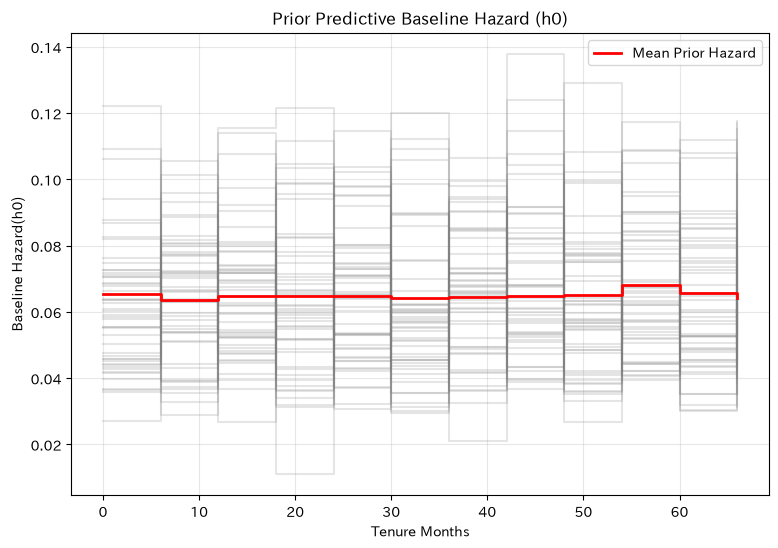

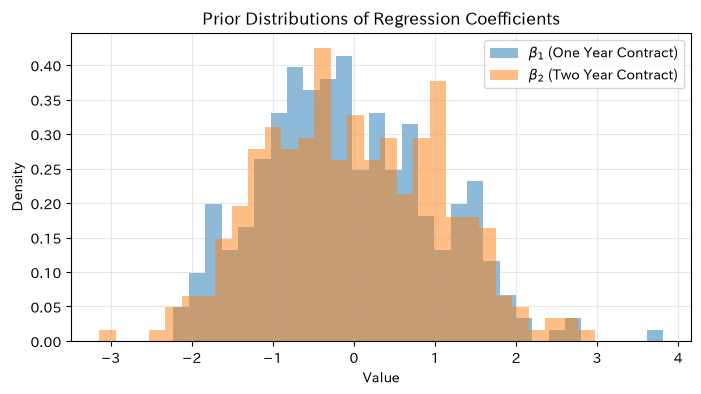

NUTS[numpyro]: [h0, beta1, beta2]
Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]


Running chain 1:   5%|████                                                                            | 200/4000 [00:

divergences: 0


Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]

  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]

Compiling.. :   0%|                                                                                               | 0/4000 [00:00<?, ?it/s]


  0%|                                                                                                             | 0/4000 [00:00<?, ?it/s]


Running chain 1:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]

Running chain 2:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]


Running chain 3:   0%|                                                                                            | 0/4000 [00:00<?, ?it/s]

Running ch

divergences: 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta1,-1.598,0.218,-2,-1.3,8233,5668,1.00,0.0024,0.0018
beta2,-3.67,0.457,-4.4,-3,8543,6320,1.00,0.005,0.0037
h0[0],0.02724,0.00272,0.023,0.032,9054,6366,1.00,2.9e-05,2.1e-05
h0[1],0.01407,0.00269,0.01,0.019,9678,6141,1.00,2.7e-05,2e-05
h0[2],0.02204,0.00392,0.016,0.029,9583,5938,1.00,4e-05,3e-05
h0[3],0.02366,0.00444,0.017,0.031,9729,6274,1.00,4.5e-05,3.3e-05
h0[4],0.01954,0.00442,0.013,0.027,9346,5651,1.00,4.4e-05,3.5e-05
h0[5],0.027,0.00529,0.019,0.036,9285,5715,1.00,5.4e-05,3.8e-05
h0[6],0.0262,0.006,0.018,0.036,9506,5763,1.00,5.9e-05,4.5e-05
h0[7],0.0275,0.0064,0.018,0.038,9359,6341,1.00,6.6e-05,5.1e-05


In [57]:
#その他のリスク
model_competition = build_cause_specific_model("other_event")

with model_competition:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)
prior

h0_prior = prior.prior["h0"].values.reshape(-1, n_intervals)
print("h0 事前分布（平均）:", h0_prior.mean(axis=0).round(4))
plt.figure(figsize=(9, 6))

num_lines = 50
for i in range(num_lines):
    plt.step(breaks[:-1], h0_prior[i], where="post", alpha=0.2, color="gray")

plt.step(breaks[:-1], h0_prior.mean(axis=0), where="post", color="red", linewidth=2, label="Mean Prior Hazard")

plt.xlabel("Tenure Months")
plt.ylabel("Baseline Hazard(h0)")
plt.title("Prior Predictive Baseline Hazard (h0)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



beta1_prior = prior.prior["beta1"].values.flatten()
beta2_prior = prior.prior["beta2"].values.flatten()
plt.figure(figsize=(8, 4))
plt.hist(beta1_prior, bins=30, alpha=0.5, density=True, label=r"$\beta_1$ (One Year Contract)")
plt.hist(beta2_prior, bins=30, alpha=0.5, density=True, label=r"$\beta_2$ (Two Year Contract)")


plt.title("Prior Distributions of Regression Coefficients")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

with model_competition:
    idata_competition = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_competition.sample_stats.diverging.sum()))
az.summary(idata_competition)

with model_competition:
    idata_competition = pm.sample(
        draws=2000, tune=2000, chains=4, cores=4,
        target_accept=0.95, nuts_sampler="numpyro", random_seed=42)

print("divergences:", int(idata_competition.sample_stats.diverging.sum()))
az.summary(idata_competition)

# Telco Churn Competing Risks Model セッションサマリー

## 目的

生存時間分析シリーズ(Exponential/Weibull/Cox/Frailty)の発展として、**「解約」という単一のイベントではなく、"どの理由で解約したか"という複数の競合するイベント種別**を区別するCompeting risksモデルに取り組んだ。Frailty modelで指摘した「Bank transferの解約が残高不足による強制解約では」という仮説を、直接検証できるデータ構造への拡張。

## データ

- IBM拡張版Telco Customer Churnデータ(33列、`Churn Reason`・`Churn Category`相当の列を含む)。ユーザーがKaggle経由で取得。
- `Churn Reason`は20種類の詳細理由があり、そのままではカテゴリごとのイベント数が少なすぎる(平均100人未満)ことを指摘し、5つの上位カテゴリに手動統合:

| 統合カテゴリ | n(解約者数) |
|---|---|
| Competitor(競合他社への乗り換え) | 621 |
| Price(価格) | 426 |
| Dissatisfaction(製品・サービス不満) | 366 |
| Support(サポート品質) | 243 |
| Other(引っ越し・死亡等、非行動要因) | 213 |

## 設計上の重要な議論: 「非行動要因」の扱い

`Moved`(引っ越し)・`Deceased`(死亡)を「解約要因ではない」としてデータから除外する案が最初に出たが、これは**informative censoring**(打ち切りの理由が真のイベント時刻と関連している)という、生存時間分析で最も警戒すべきバイアスを生む可能性を指摘し、**除外せず「第5の競合リスク」として残す**方針に変更。解釈の際に「これは行動的な解約ではなく、観測終了に近い性質を持つ」ことを明記する形で対応した。

## モデル構造: Cause-specific hazard

$$h_k(t) = h_{0,k}(t)\times\exp(x^\top\beta_k), \quad k=1,\dots,5$$

各カテゴリについて、「そのカテゴリの解約=1、それ以外(他カテゴリの解約または打ち切り)=0」という5つの独立な0/1列を作成し、Piecewise Exponential(Coxモデル)を5回、各カテゴリごとに独立してフィットする、cause-specific hazardアプローチを採用。階層構造(カテゴリ間の情報共有)の導入も検討したが、まず独立フィットで実用上十分な精度が得られるかを確認する2段階アプローチとし、実際に全カテゴリでess_bulk数千超・divergences=0という健全な結果が得られたため、階層化は見送った。

## 事前分布のスケール調整

各カテゴリの`h0`の事前分布は、前回のCoxモデル(全解約対象、$h_0[0]\approx0.197$)を出発点に、**「そのカテゴリが全解約者に占める人数比」を掛け合わせて逆算**する手順を確立(例: Competitor 621/1869≈33%→$h_0[0]\approx0.197\times0.33\approx0.065$)。この検算値は事後推定値(0.067)とほぼ一致し、精度の高い近似だったことが確認された。

## 結果: 5カテゴリの契約タイプ効果比較

| カテゴリ | β1(1年契約) | β2(2年契約) | ハザード比 exp(β2) |
|---|---|---|---|
| Competitor | -1.212 | -2.564 | 0.077 |
| Price | -1.957 | -2.752 | 0.064 |
| Dissatisfaction | -1.617 | -2.915 | 0.054 |
| Support | -1.380 | -3.353 | 0.035 |
| Other | -1.598 | -3.670 | 0.026 |

全カテゴリで長期契約がハザードを明確に抑制する一方、**抑制の強さには理由ごとに明確な差**があることが判明:

- **Price理由は1年契約の効果が最も強い**(-1.957): 価格に敏感な顧客ほど、長期契約の割引メリットにも敏感に反応すると解釈できる
- **Support/Other理由は2年契約の効果が特に強い**(-3.35, -3.67)一方、1年契約の効果はそれほど強くない: 短期の契約延長では解消しきれない不満が、より長い関係性の中では起きにくくなる可能性
- **Competitor理由は1年契約の抑制効果が5カテゴリ中最も弱い**(-1.212): 競合他社への乗り換えは契約期間の長さだけでは防ぎきれず、契約以外の対策(製品差別化・ロイヤルティ施策)が必要な領域である可能性

---

## 主要な学び

1. **カテゴリ数が多すぎる場合の統合は、慎重な理由付けが必要**: 20カテゴリをそのまま扱うとサンプルサイズ不足に陥ることを、MLB/サメでの経験(打数の少ない選手、記録の少ない国)から即座に判断し、5カテゴリへの統合を提案・実行した。
2. **「解約理由ではない」データを安易に除外すると、informative censoringのバイアスを生む**: 直感的には除外したくなる「非行動要因(引っ越し・死亡)」を、統計的により正しい形(第5の競合リスクとして保持)で扱うことで、バイアスを回避した。これは「データを都合よく削ることの危険性」という、これまでのセッション全体を貫く原則の生存時間分析版。
3. **事前分布のスケールを、既存モデルからの"比率の掛け算"で逆算する手法が確立**: 全体モデルの推定値に、サブグループの人数比を掛け合わせることで、複数の類似モデル(5カテゴリ)の事前分布を効率的かつ精度高く設定できることを実証した(検算値0.065 vs 事後値0.067)。
4. **独立フィットでも実用上十分な場合は、無理に階層化しない判断も重要**: Frailty modelで階層構造の威力を学んだ直後だが、今回は5カテゴリすべてで独立フィットが十分に安定した結果を出したため、モデルを複雑化させる階層化を見送った。「使える技術を常に使う」のではなく「必要な場面で使う」という判断も、実践的なモデリングスキルの一部。

## 生存時間分析シリーズ全体の総括

Exponential(制約が強すぎる)→Weibull(時間依存ハザード)→Cox/Piecewise Exponential(共変量効果)→Frailty(観測されないグループ差、非識別性の発見と解消)→Competing risks(複数のイベント種別)という一連の発展を通じ、生存時間分析特有の概念(打ち切り、ハザード関数、cause-specific hazard)と、これまでの階層ベイズ・非識別性診断の技法が、随所で有機的に結びつくことを確認した。「あまり習得できた気がしない」という出発点から、複数のモデルを跨いで技法を使い回せるようになった、意味のある発展だったと言える。
